In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yaml
#CSV_FILE = "/home/ddacunto/Desktop/ros2_ws/recording_csv/NOEMI_BIANCAMANO/CHECK_XY/recording_1.csv"
CSV_FILE = "/home/ddacunto/Desktop/ros2_ws/recording_csv/NOEMI_BIANCAMANO/CHECK_XZ/recording_1.csv"
YAML_PATHS_FILE = "/home/ddacunto/Desktop/ros2_ws/src/unisa_acg_ros2/haptics/haptic_interaction_teach_and_record_demo/config/paths.yaml"
with open(YAML_PATHS_FILE, "r") as f:
    yaml_data = yaml.safe_load(f)
TASK = CSV_FILE.split("/")[-2]
yaml_content = yaml_data["paths"]
for path in yaml_content:
    if path["name"] == TASK:
        WAYPOINTS = path["waypoints"]
        break
csv_data = pd.read_csv(CSV_FILE)
print(WAYPOINTS)
csv_data.head(10)

[{'x': 0.15, 'y': 0.5, 'z': 0.5}, {'x': 0.4, 'y': 0.15, 'z': 0.5}, {'x': 0.9, 'y': 0.85, 'z': 0.5}]


,timestamp,position_x,position_y,position_z,orientation_x,orientation_y,orientation_z,twist_linear_x,twist_linear_y,twist_linear_z
0,1790946741875819999,-0.069156,-0.013184,-0.000037,-0.176537,0.173551,0.102834,0.002437,0.003283,-0.000015
1,1790946741877832175,-0.069150,-0.013177,-0.000037,-0.176571,0.173594,0.102832,0.003122,0.003274,0.000269
2,1790946741879854807,-0.069144,-0.013170,-0.000036,-0.176606,0.173637,0.102829,0.003122,0.003273,0.000269
3,1790946741881805118,-0.069137,-0.013164,-0.000036,-0.176640,0.173680,0.102826,0.003126,0.003277,0.000269
4,1790946741883848585,-0.069132,-0.013159,-0.000036,-0.176671,0.173719,0.102825,0.002489,0.002535,-0.000152
5,1790946741885865252,-0.069127,-0.013154,-0.000036,-0.176703,0.173757,0.102824,0.002494,0.002540,-0.000152
6,1790946741887799425,-0.069122,-0.013149,-0.000037,-0.176734,0.173796,0.102822,0.002483,0.002529,-0.000151
7,1790946741889921439,-0.069118,-0.013145,-0.000036,-0.176766,0.173834,0.102821,0.002254,0.001638,0.000419
8,1790946741891848163,-0.069113,-0.013142,-0.000035,-0.176797,0.173872,0.102820,0.002255,0.001639,0.000419
9,1790946741893841677,-0.069109,-0.013139,-0.000034,-0.176829,0.173911,0.102818,0.002253,0.001638,0.000419


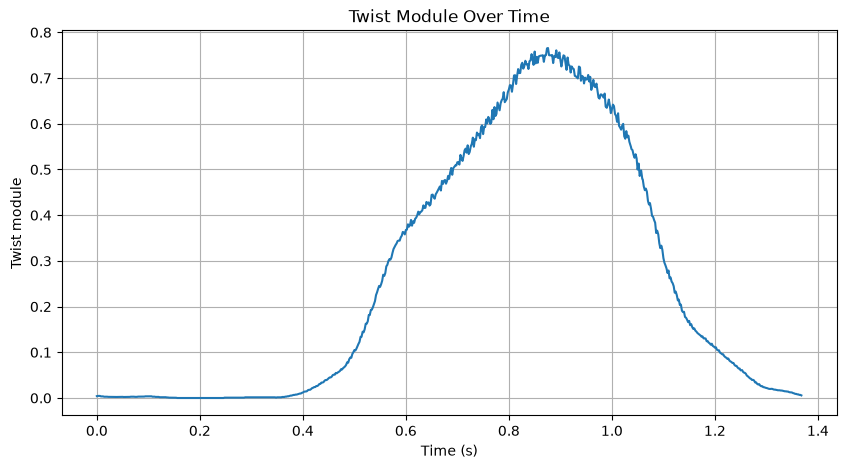

In [11]:
time_seconds = (csv_data["timestamp"] - csv_data["timestamp"].iloc[0]) / 1e9

twist_module = (
    csv_data[["twist_linear_x", "twist_linear_y", "twist_linear_z"]]
    .pow(2)
    .sum(axis=1)
    .pow(0.5)
)

plt.figure(figsize=(10, 5))
plt.plot(time_seconds, twist_module)
plt.xlabel("Time (s)")
plt.ylabel("Twist module")
plt.title("Twist Module Over Time")
plt.grid(True)
plt.show()

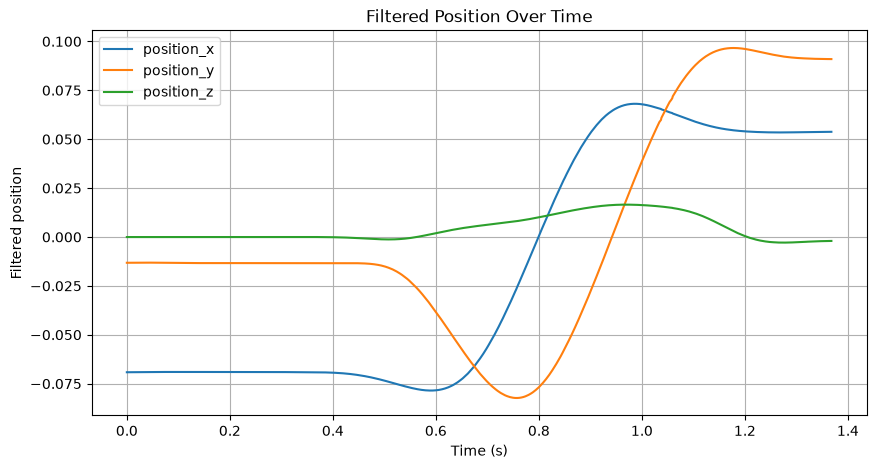

In [12]:
from scipy.signal import cheby2, filtfilt

def chebyshev_filter(data, position=True, order=11, cutoff_hz=16, stopband_db=80):
    dt = data["timestamp"].diff().dropna().median() / 1e9
    sampling_hz = 1 / dt
    nyquist_hz = sampling_hz / 2

    if not 0 < cutoff_hz < nyquist_hz:
        raise ValueError(
            f"cutoff_hz must be in (0, {nyquist_hz:.2f}) Hz."
        )

    b, a = cheby2(
        order,
        stopband_db,
        cutoff_hz / nyquist_hz,
        btype="low",
    )

    filtered_data = data.copy()

    columns = (
        ["position_x", "position_y", "position_z"]
        if position
        else ["twist_linear_x", "twist_linear_y", "twist_linear_z"]
    )

    filtered_data[columns] = filtfilt(
        b,
        a,
        data[columns].to_numpy(),
        axis=0,
    )

    return filtered_data


filtered_csv_data = chebyshev_filter(csv_data)

plt.figure(figsize=(10, 5))
for column in ["position_x", "position_y", "position_z"]:
    plt.plot(
        time_seconds,
        filtered_csv_data[column],
        label=column,
    )

plt.xlabel("Time (s)")
plt.ylabel("Filtered position")
plt.title("Filtered Position Over Time")
plt.grid(True)
plt.legend()
plt.show()
position_columns = ["position_x", "position_y", "position_z"]

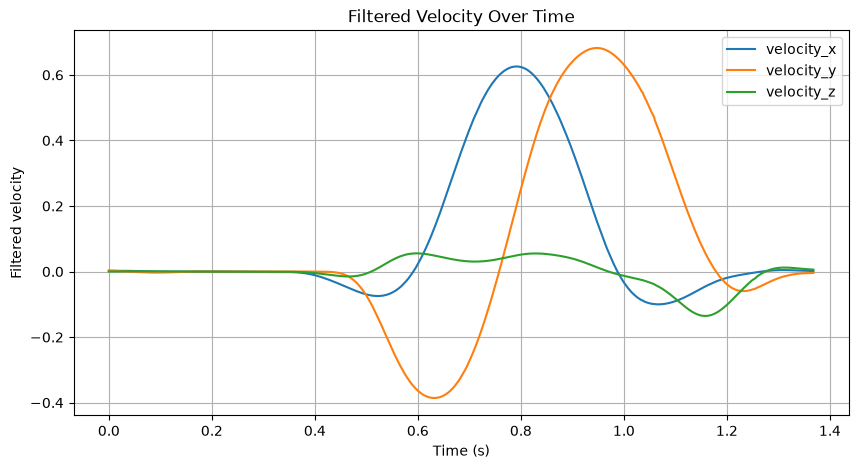

In [13]:
filtered_velocity_data = chebyshev_filter(
    csv_data,
    position=False,
)

velocity_columns = [
    "twist_linear_x",
    "twist_linear_y",
    "twist_linear_z",
]

plt.figure(figsize=(10, 5))

for column in velocity_columns:
    plt.plot(
        time_seconds,
        filtered_velocity_data[column],
        label=column.replace("twist_linear_", "velocity_"),
    )

plt.xlabel("Time (s)")
plt.ylabel("Filtered velocity")
plt.title("Filtered Velocity Over Time")
plt.grid(True)
plt.legend()
plt.show()


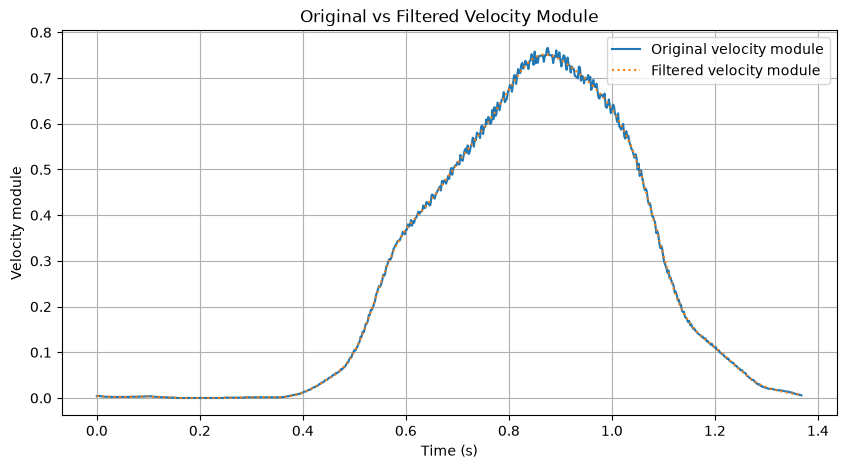

In [14]:
filtered_velocity_module = (
    filtered_velocity_data[velocity_columns]
    .pow(2)
    .sum(axis=1)
    .pow(0.5)
)

plt.figure(figsize=(10, 5))
plt.plot(time_seconds, twist_module, label="Original velocity module")
plt.plot(
    time_seconds,
    filtered_velocity_module,
    label="Filtered velocity module",
    linestyle=":"
)

plt.xlabel("Time (s)")
plt.ylabel("Velocity module")
plt.title("Original vs Filtered Velocity Module")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
from scipy.signal import savgol_filter, find_peaks

def _robust_sigma(values):
    values = np.asarray(values, dtype=float)
    return 1.4826 * np.median(np.abs(values - np.median(values)))


def cut_boundary_strokes(
    traj,
    smooth_win=0.04,
    prom_k=3,
    prom_frac=0.02,
    rest_percent=10,
    thr_k=3,
    ref_dur=0.15,
    len_thr=None,
    rel_vmax=0.20,
    edge_frac=(0.0, 0.0),
):
    p = np.asarray(traj["p"], dtype=float)
    v = np.asarray(traj["v"], dtype=float).reshape(-1)
    t = np.asarray(traj["t"], dtype=float).reshape(-1)

    n = len(t)
    if p.shape != (n, 3) or len(v) != n:
        raise ValueError("p deve essere Nx3; v e t devono avere N elementi.")
    if np.any(np.diff(t) <= 0):
        raise ValueError("t deve essere strettamente crescente.")

    fs = (n - 1) / (t[-1] - t[0])

    window = max(5, 2 * round(smooth_win * fs / 2) + 1)
    window = min(window, n if n % 2 else n - 1)
    window = max(3, window)

    polyorder = min(3, window - 1)
    vs = savgol_filter(v, window, polyorder)

    sigma = _robust_sigma(v - vs)
    prominence = max(prom_k * sigma, prom_frac * np.max(vs))

    minima, _ = find_peaks(-vs, prominence=prominence)
    boundaries = np.unique(np.r_[0, minima, n - 1])

    k_strokes = len(boundaries) - 1
    duration = np.diff(t[boundaries])
    lengths = np.zeros(k_strokes)
    vmax = np.zeros(k_strokes)

    for k in range(k_strokes):
        segment = slice(boundaries[k], boundaries[k + 1] + 1)
        lengths[k] = np.trapezoid(v[segment], t[segment])
        vmax[k] = np.max(v[segment])

    sorted_vs = np.sort(vs)
    n_low = max(5, int(np.ceil(n * rest_percent / 100)))
    low_speed = sorted_vs[:n_low]

    noise_speed = np.median(low_speed) + _robust_sigma(low_speed)
    if len_thr is None:
        len_thr = thr_k * noise_speed * ref_dur

    weak = (lengths < len_thr) | (vmax < rel_vmax * np.max(vmax))

    n_cut_left = 0
    while n_cut_left < k_strokes - 1 and weak[n_cut_left]:
        n_cut_left += 1

    n_cut_right = 0
    while (
        n_cut_left + n_cut_right < k_strokes - 1
        and weak[k_strokes - 1 - n_cut_right]
    ):
        n_cut_right += 1

    idx_left = boundaries[n_cut_left]
    idx_right = boundaries[k_strokes - n_cut_right]

    while (
        edge_frac[0] > 0
        and idx_left < idx_right
        and vs[idx_left] < edge_frac[0] * vmax[n_cut_left]
    ):
        idx_left += 1

    while (
        edge_frac[1] > 0
        and idx_right > idx_left
        and vs[idx_right] < edge_frac[1] * vmax[k_strokes - 1 - n_cut_right]
    ):
        idx_right -= 1

    keep = np.arange(idx_left, idx_right + 1)

    out = {
        "p": p[keep],
        "v": v[keep],
        "t": t[keep],
        "f": (len(keep) - 1) / (t[idx_right] - t[idx_left]),
    }

    info = {
        "strokes": pd.DataFrame({
            "iStart": boundaries[:-1],
            "iEnd": boundaries[1:],
            "duration": duration,
            "length": lengths,
            "vmax": vmax,
            "belowThr": weak,
        }),
        "lenThr": len_thr,
        "noiseSpeed": noise_speed,
        "prominence": prominence,
        "nCutLeft": n_cut_left,
        "nCutRight": n_cut_right,
        "idxLeft": idx_left,
        "idxRight": idx_right,
        "keep": keep,
    }

    return out, info


traj = {
    "p": filtered_csv_data[["position_x", "position_y", "position_z"]].to_numpy(),
    "v": filtered_velocity_module.to_numpy(),
    "t": time_seconds.to_numpy(),
    "f": 1 / np.median(np.diff(time_seconds)),
}

cut_traj, cut_info = cut_boundary_strokes(traj)

cut_info["strokes"], cut_info["idxLeft"], cut_info["idxRight"]

(   iStart  iEnd  duration    length      vmax  belowThr
 0       0   684  1.367981  0.349984  0.751668     False,
 np.int64(0),
 np.int64(684))

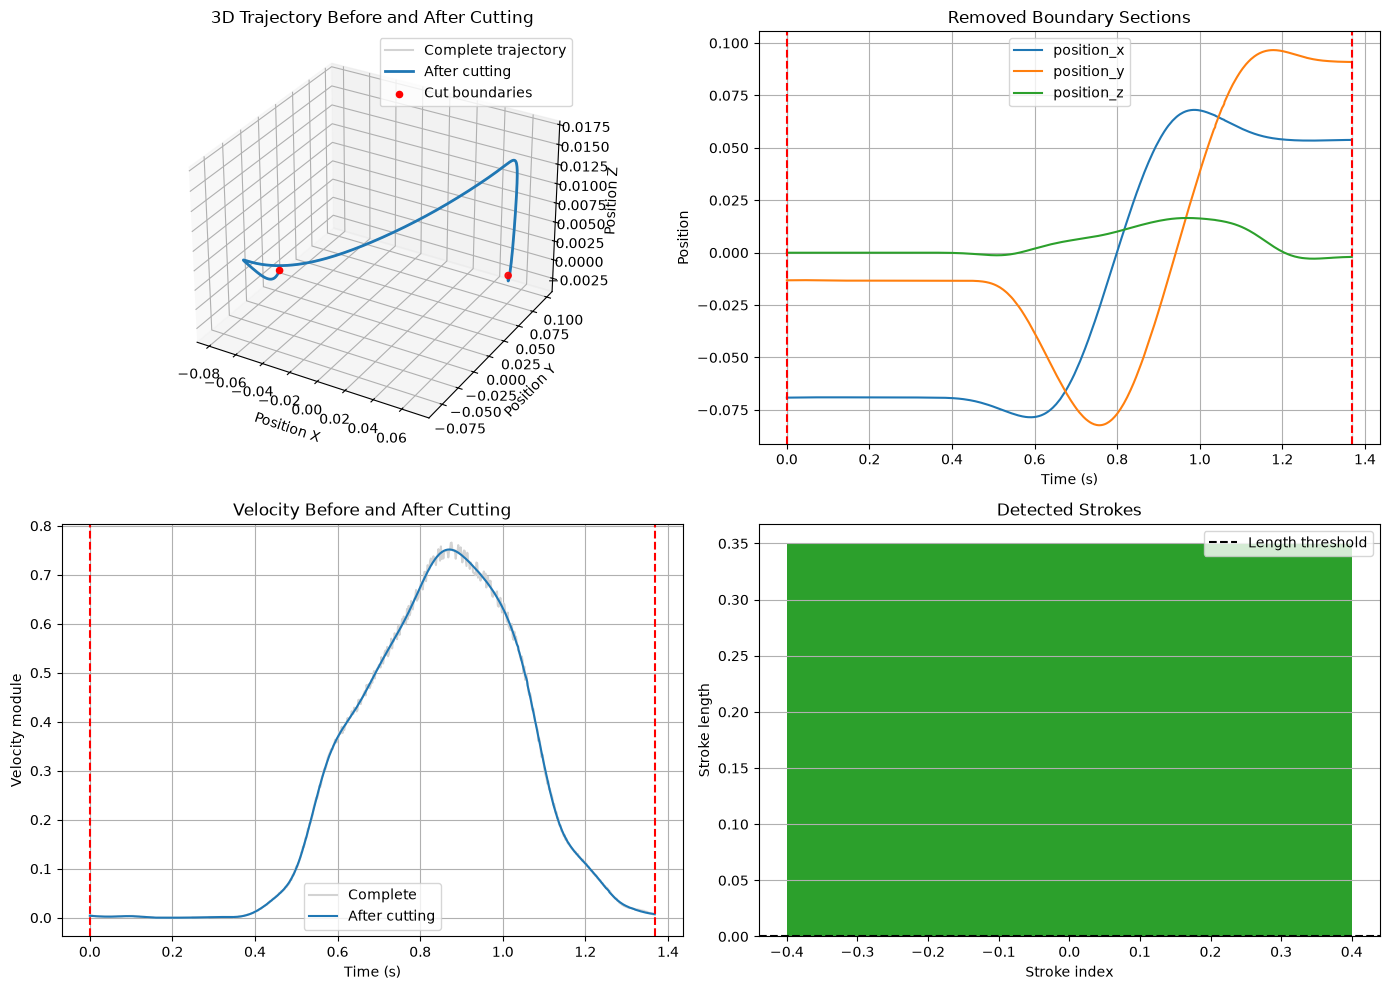

In [16]:
idx_left = int(cut_info["idxLeft"])
idx_right = int(cut_info["idxRight"])

position_xyz = filtered_csv_data[
    ["position_x", "position_y", "position_z"]
].to_numpy(dtype=float)
cut_position_xyz = np.asarray(cut_traj["p"], dtype=float)
time_values = time_seconds.to_numpy(dtype=float)

boundary_indices = np.array([idx_left, idx_right], dtype=int)

fig = plt.figure(figsize=(14, 10))

# Position in 3D
ax1 = fig.add_subplot(2, 2, 1, projection="3d")
ax1.plot(
    position_xyz[:, 0],
    position_xyz[:, 1],
    position_xyz[:, 2],
    color="lightgray",
    label="Complete trajectory",
)
ax1.plot(
    cut_position_xyz[:, 0],
    cut_position_xyz[:, 1],
    cut_position_xyz[:, 2],
    color="tab:blue",
    linewidth=2,
    label="After cutting",
)
ax1.scatter(
    position_xyz[boundary_indices, 0],
    position_xyz[boundary_indices, 1],
    position_xyz[boundary_indices, 2],
    color="red",
    zorder=3,
    label="Cut boundaries",
)
ax1.set_xlabel("Position X")
ax1.set_ylabel("Position Y")
ax1.set_zlabel("Position Z")
ax1.set_title("3D Trajectory Before and After Cutting")
ax1.legend()

# Position components over time
ax2 = fig.add_subplot(2, 2, 2)
for col in position_columns:
    ax2.plot(time_values, filtered_csv_data[col].to_numpy(), label=col)

ax2.axvspan(time_values[0], time_values[idx_left], color="gray", alpha=0.25)
ax2.axvspan(time_values[idx_right], time_values[-1], color="gray", alpha=0.25)
ax2.axvline(time_values[idx_left], color="red", linestyle="--")
ax2.axvline(time_values[idx_right], color="red", linestyle="--")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position")
ax2.set_title("Removed Boundary Sections")
ax2.grid(True)
ax2.legend()

# Velocity module
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(time_values, twist_module.to_numpy(), color="lightgray", label="Complete")
ax3.plot(cut_traj["t"], cut_traj["v"], color="tab:blue", label="After cutting")
ax3.axvline(time_values[idx_left], color="red", linestyle="--")
ax3.axvline(time_values[idx_right], color="red", linestyle="--")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Velocity module")
ax3.set_title("Velocity Before and After Cutting")
ax3.grid(True)
ax3.legend()

# Stroke classification
ax4 = fig.add_subplot(2, 2, 4)
strokes = cut_info["strokes"]
stroke_lengths = strokes["length"].to_numpy(dtype=float)
stroke_colors = [
    "tab:red" if below else "tab:green"
    for below in strokes["belowThr"].to_numpy()
]

ax4.bar(
    np.arange(len(strokes)),
    stroke_lengths,
    color=stroke_colors,
)
ax4.axhline(
    float(cut_info["lenThr"]),
    color="black",
    linestyle="--",
    label="Length threshold",
)
ax4.set_xlabel("Stroke index")
ax4.set_ylabel("Stroke length")
ax4.set_title("Detected Strokes")
ax4.grid(True, axis="y")
ax4.legend()

plt.tight_layout()
plt.show()

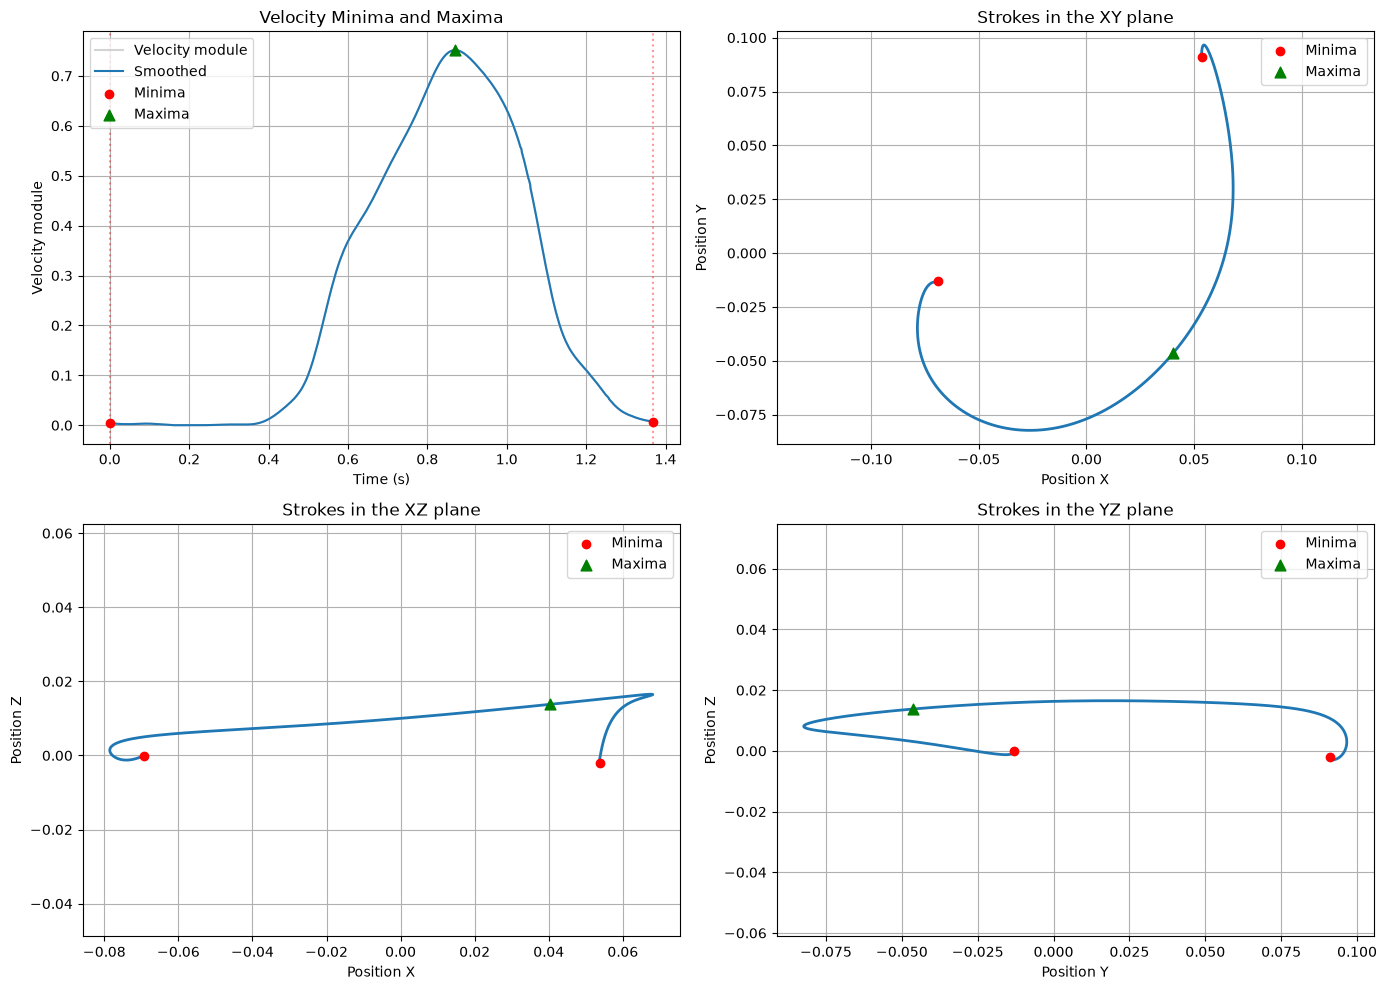

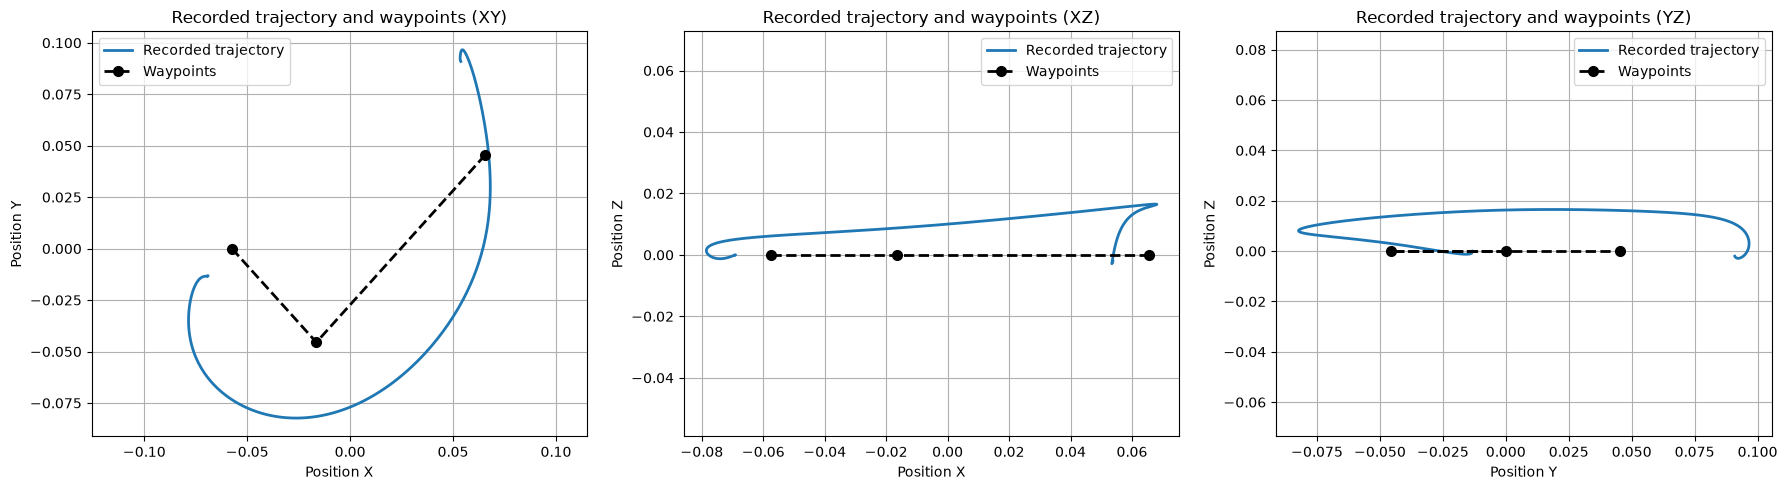

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

SWAP_YZ_WAYPOINTS = False
WS_MIN = [-0.082, -0.065, -0.085]
WS_MAX = [0.082, 0.065, 0.085]
# Waypoints are normalized (as in plot_paths.py). To overlay them on the recorded
# positions they must be expressed in the same frame and units as the device data.

def waypoints_to_array(waypoints, swap_yz=False, ws_min=None, ws_max=None):
    """Convert the list of {'x','y','z'} dicts into an Nx3 array in device coordinates."""
    arr = np.array([[w["x"], w["y"], w["z"]] for w in waypoints], dtype=float)
    if swap_yz:
        arr[:, [1, 2]] = arr[:, [2, 1]]
    if ws_min is not None and ws_max is not None:
        ws_min = np.asarray(ws_min, dtype=float)
        ws_max = np.asarray(ws_max, dtype=float)
        arr = ws_min + arr * (ws_max - ws_min)
    return arr




def _robust_sigma(values):
    values = np.asarray(values, dtype=float)
    return 1.4826 * np.median(np.abs(values - np.median(values)))


def detect_strokes(traj, smooth_win=0.04, prom_k=3, prom_frac=0.02):
    """Return smoothed speed, stroke boundaries (speed minima) and one speed maximum per stroke."""
    v = np.asarray(traj["v"], dtype=float).reshape(-1)
    t = np.asarray(traj["t"], dtype=float).reshape(-1)
    n = len(t)
    fs = (n - 1) / (t[-1] - t[0])

    # Same smoothing as cut_boundary_strokes
    window = max(5, 2 * round(smooth_win * fs / 2) + 1)
    window = min(window, n if n % 2 else n - 1)
    window = max(3, window)
    polyorder = min(3, window - 1)
    vs = savgol_filter(v, window, polyorder)

    # Same prominence threshold as cut_boundary_strokes
    sigma = _robust_sigma(v - vs)
    prominence = max(prom_k * sigma, prom_frac * np.max(vs))

    minima, _ = find_peaks(-vs, prominence=prominence)
    boundaries = np.unique(np.r_[0, minima, n - 1])

    # One maximum per stroke: the highest smoothed speed between two consecutive minima
    maxima = np.array([
        boundaries[k] + np.argmax(vs[boundaries[k] : boundaries[k + 1] + 1])
        for k in range(len(boundaries) - 1)
    ])

    return vs, boundaries, maxima


def plot_strokes(traj, vs, boundaries, maxima):
    t = np.asarray(traj["t"], dtype=float)
    v = np.asarray(traj["v"], dtype=float)
    p = np.asarray(traj["p"], dtype=float)

    n_strokes = len(boundaries) - 1
    colors = plt.cm.tab10(np.arange(n_strokes) % 10)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax_v, ax_xy, ax_xz, ax_yz = axes.ravel()

    # Speed over time
    ax_v.plot(t, v, color="lightgray", label="Velocity module")
    ax_v.plot(t, vs, color="tab:blue", label="Smoothed")
    ax_v.scatter(t[boundaries], vs[boundaries], color="red", zorder=3, label="Minima")
    ax_v.scatter(t[maxima], vs[maxima], color="green", marker="^", s=60, zorder=3, label="Maxima")
    for b in boundaries:
        ax_v.axvline(t[b], color="red", linestyle=":", alpha=0.4)
    ax_v.set_xlabel("Time (s)")
    ax_v.set_ylabel("Velocity module")
    ax_v.set_title("Velocity Minima and Maxima")
    ax_v.grid(True)
    ax_v.legend()

    # Space: the three coordinate planes, path colored by stroke
    planes = [
        (ax_xy, 0, 1, "X", "Y"),
        (ax_xz, 0, 2, "X", "Z"),
        (ax_yz, 1, 2, "Y", "Z"),
    ]
    for ax, i, j, xl, yl in planes:
        for k in range(n_strokes):
            seg = slice(boundaries[k], boundaries[k + 1] + 1)
            ax.plot(p[seg, i], p[seg, j], color=colors[k], linewidth=2)
        ax.scatter(p[boundaries, i], p[boundaries, j], color="red", zorder=3, label="Minima")
        ax.scatter(p[maxima, i], p[maxima, j], color="green", marker="^", s=60, zorder=3, label="Maxima")
        ax.set_xlabel(f"Position {xl}")
        ax.set_ylabel(f"Position {yl}")
        ax.set_title(f"Strokes in the {xl}{yl} plane")
        ax.axis("equal")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


vs, boundaries, maxima = detect_strokes(cut_traj)  # use `traj` for the uncut trajectory
plot_strokes(cut_traj, vs, boundaries, maxima)

# Overlay recorded positions and task waypoints in the same coordinate frame.
waypoints_arr = waypoints_to_array(
    WAYPOINTS,
    swap_yz=SWAP_YZ_WAYPOINTS,
    ws_min=WS_MIN,
    ws_max=WS_MAX,
)

p = np.asarray(cut_traj["p"], dtype=float)
n_strokes = len(boundaries) - 1
colors = plt.cm.tab10(np.arange(n_strokes) % 10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
planes = [
    (0, 1, "X", "Y"),
    (0, 2, "X", "Z"),
    (1, 2, "Y", "Z"),
]

for ax, (i, j, xlabel, ylabel) in zip(axes, planes):
    for k in range(n_strokes):
        segment = slice(boundaries[k], boundaries[k + 1] + 1)
        ax.plot(
            p[segment, i],
            p[segment, j],
            color=colors[k],
            linewidth=2,
            label="Recorded trajectory" if k == 0 else None,
        )

    ax.plot(
        waypoints_arr[:, i],
        waypoints_arr[:, j],
        "k--o",
        linewidth=2,
        markersize=7,
        label="Waypoints",
    )

    ax.set_xlabel(f"Position {xlabel}")
    ax.set_ylabel(f"Position {ylabel}")
    ax.set_title(f"Recorded trajectory and waypoints ({xlabel}{ylabel})")
    ax.axis("equal")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

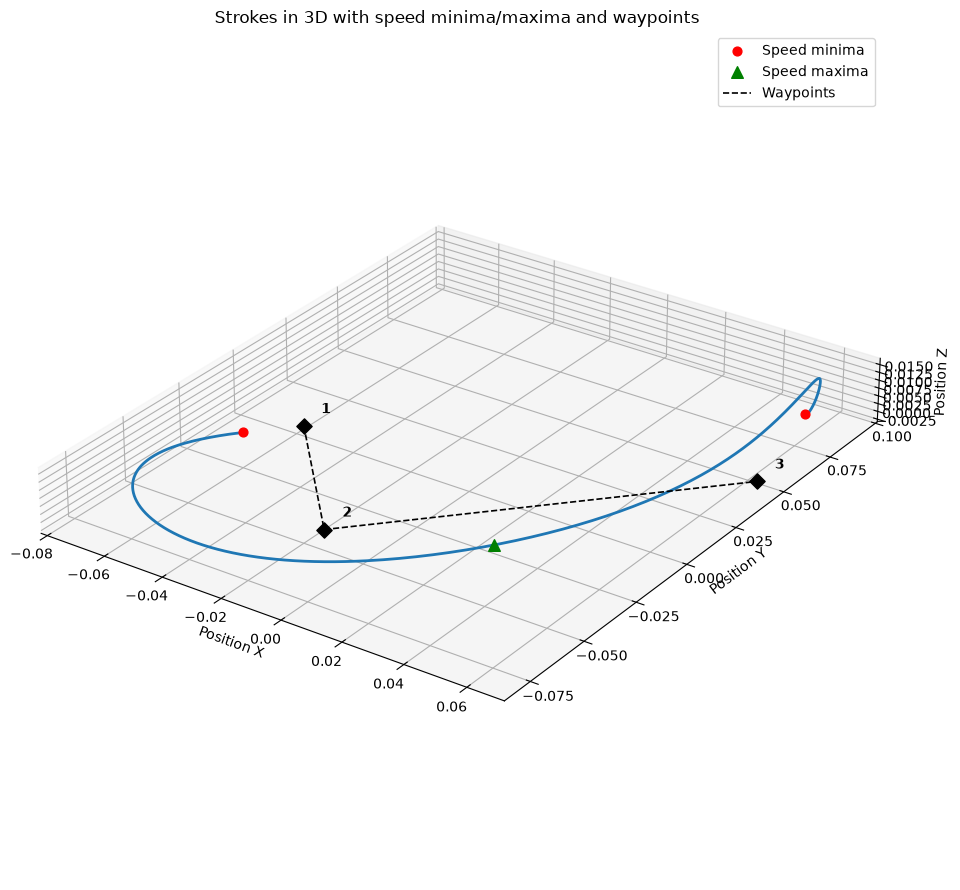

In [18]:
import numpy as np
import matplotlib.pyplot as plt
def plot_strokes_3d(traj, boundaries, maxima, waypoints=None, elev=28.0, azim=-55.0):
    p = np.asarray(traj["p"], dtype=float)
    n_strokes = len(boundaries) - 1
    colors = plt.cm.tab10(np.arange(n_strokes) % 10)

    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection="3d")

    # Path, one color per stroke
    for k in range(n_strokes):
        seg = slice(boundaries[k], boundaries[k + 1] + 1)
        ax.plot(p[seg, 0], p[seg, 1], p[seg, 2], color=colors[k], linewidth=2)

    # Speed minima (stroke boundaries) and maxima (one per stroke)
    ax.scatter(*p[boundaries].T, color="red", s=40, depthshade=False, label="Speed minima")
    ax.scatter(*p[maxima].T, color="green", marker="^", s=70, depthshade=False, label="Speed maxima")

    all_pts = [p]
    if waypoints is not None:
        wp = np.asarray(waypoints, dtype=float)
        ax.plot(*wp.T, color="black", linestyle="--", linewidth=1.2, label="Waypoints")
        ax.scatter(*wp.T, color="black", marker="D", s=60, depthshade=False)
        offset = 0.02 * np.ptp(np.vstack([p, wp]), axis=0).max()
        for i, (x, y, z) in enumerate(wp, start=1):
            ax.text(x + offset, y + offset, z + offset, str(i), fontsize=10, fontweight="bold")
        all_pts.append(wp)

    # Equal scale on the three axes (limits and box aspect share the same ranges)
    pts = np.vstack(all_pts)
    center = (pts.max(axis=0) + pts.min(axis=0)) / 2
    ranges = np.ptp(pts, axis=0)
    ranges = np.maximum(ranges, 0.1 * ranges.max())  # avoid a flat axis if one coordinate is constant
    half = 0.525 * ranges
    ax.set_xlim(center[0] - half[0], center[0] + half[0])
    ax.set_ylim(center[1] - half[1], center[1] + half[1])
    ax.set_zlim(center[2] - half[2], center[2] + half[2])
    ax.set_box_aspect(ranges)

    ax.set_xlabel("Position X")
    ax.set_ylabel("Position Y")
    ax.set_zlabel("Position Z")
    ax.set_title("Strokes in 3D with speed minima/maxima and waypoints")
    ax.view_init(elev=elev, azim=azim)
    ax.legend()
    plt.tight_layout()
    plt.show()


waypoints_arr = waypoints_to_array(WAYPOINTS, SWAP_YZ_WAYPOINTS, WS_MIN, WS_MAX)
plot_strokes_3d(cut_traj, boundaries, maxima, waypoints_arr)